In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss

In [ ]:
data = pd.read_csv('test.csv')

In [ ]:
data.head()

,S.no,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,1,80,0,8,0,1,6-10 Years,4,0,5
1,2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,4,80,1,10,3,3,6-10 Years,7,1,7
2,3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,2,80,0,7,3,3,Infant Attrition,0,0,0
3,4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,3,80,0,8,3,3,6-10 Years,7,3,0
4,5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,1-5 Years,2,2,2


In [ ]:
def make_table_and_plot(col_name, title=None):
    # Create pivot table
    table = pd.crosstab(
        data[col_name],
        data["Attrition"],
        margins=True,
        margins_name="Grand Total"
    )

    # Drop Grand Total for plotting
    table_plot = table.drop("Grand Total")

    # --- Plot stacked bar ---
    ax = table_plot[["No", "Yes"]].plot(
        kind="bar",
        stacked=True,
        figsize=(8, 5),
        color=["skyblue", "salmon"]
    )

    # Remove y-axis ticks and label
    ax.set_yticks([])
    ax.set_ylabel("")

    # Add labels on bars
    for i, (index, row) in enumerate(table_plot.iterrows()):
        no_height = row["No"]
        yes_height = row["Yes"]

        # Label for "No" section
        ax.text(i, no_height / 2, str(no_height), ha='center', va='center', fontsize=10)
        # Label for "Yes" section
        ax.text(i, no_height + yes_height / 2, str(yes_height), ha='center', va='center', fontsize=10)

    # Titles and layout
    plt.title(title or f"Attrition by {col_name}", fontsize=14)
    plt.xlabel(col_name, fontsize=12)
    plt.legend(title="Attrition", fontsize=10)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return table

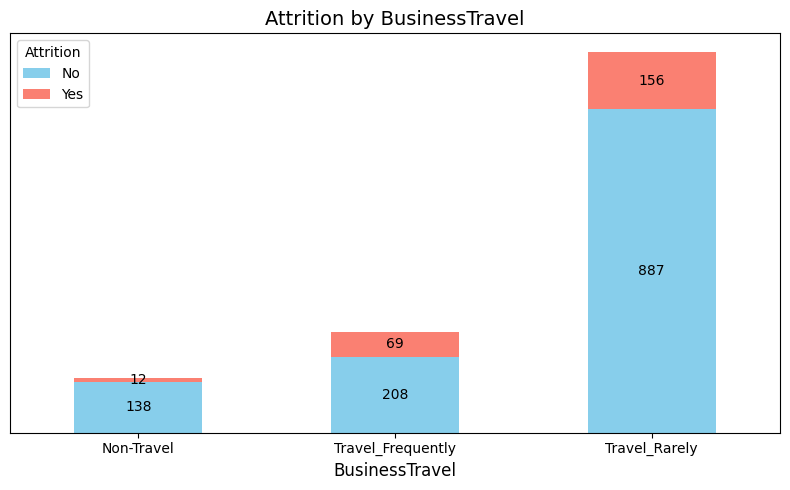

In [ ]:
biss_table = make_table_and_plot("BusinessTravel")

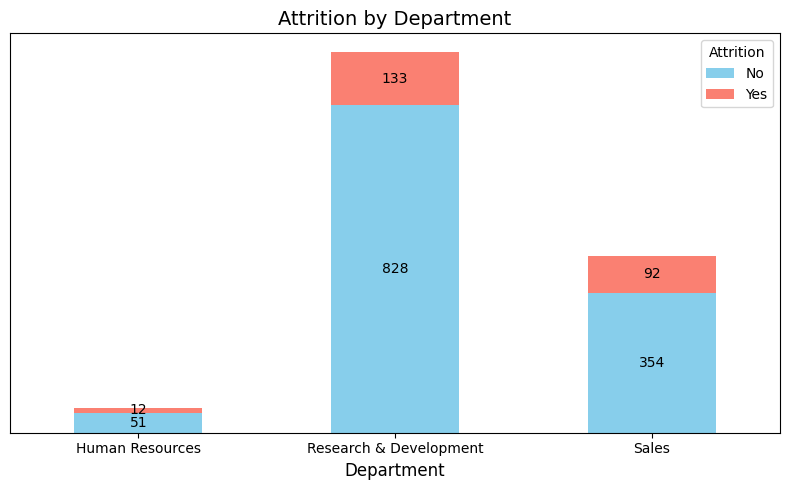

In [ ]:
dept_table = make_table_and_plot("Department")

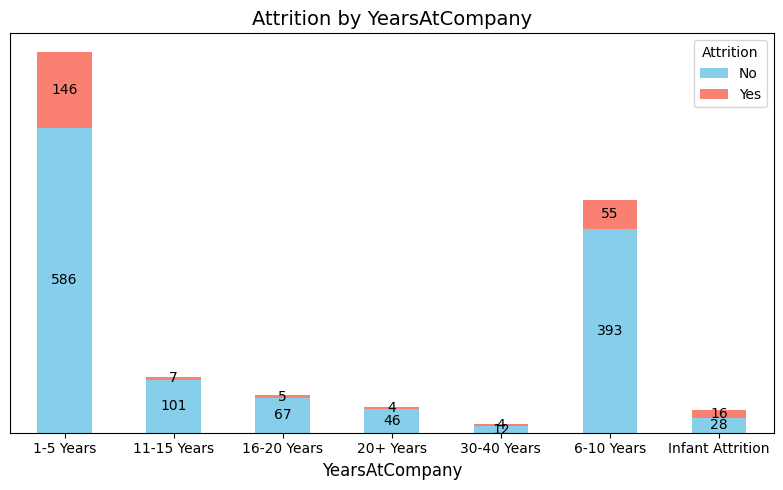

In [ ]:
years_table = make_table_and_plot("YearsAtCompany")

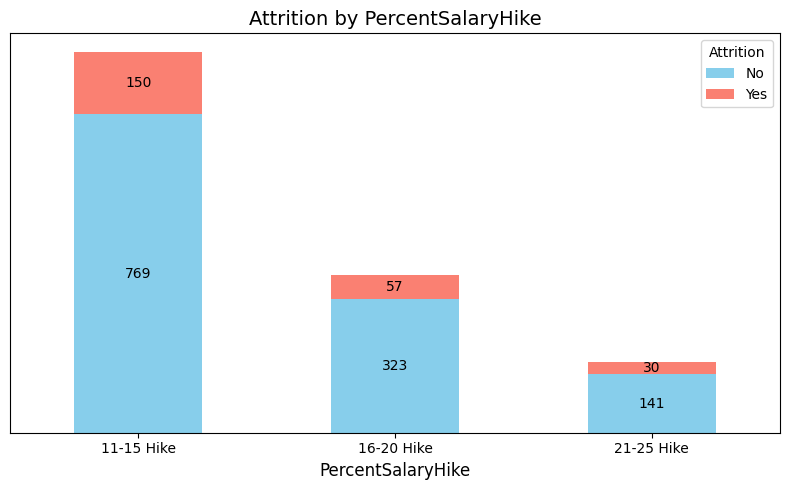

In [ ]:
hike_table = make_table_and_plot("PercentSalaryHike")

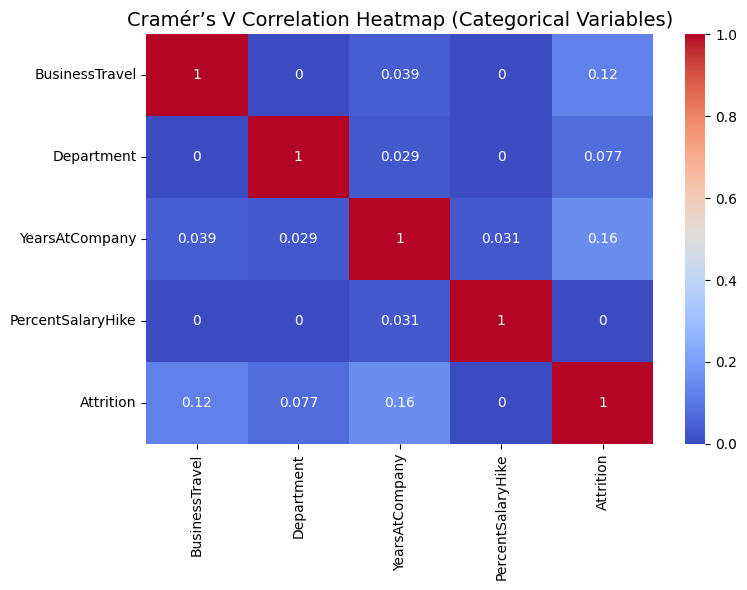

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# --- Load your data ---
df = pd.read_csv("test.csv")

# --- Define the categorical columns you want to compare ---
cols = ["BusinessTravel", "Department", "YearsAtCompany", "PercentSalaryHike", "Attrition"]

# --- Function to compute Cramér’s V between two categorical variables ---
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# --- Compute correlation matrix for all pairs ---
cramers_results = pd.DataFrame(index=cols, columns=cols)

for col1 in cols:
    for col2 in cols:
        cramers_results.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Convert to float
cramers_results = cramers_results.astype(float)

# --- Plot Heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(cramers_results, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Cramér’s V Correlation Heatmap (Categorical Variables)", fontsize=14)
plt.tight_layout()
plt.show()


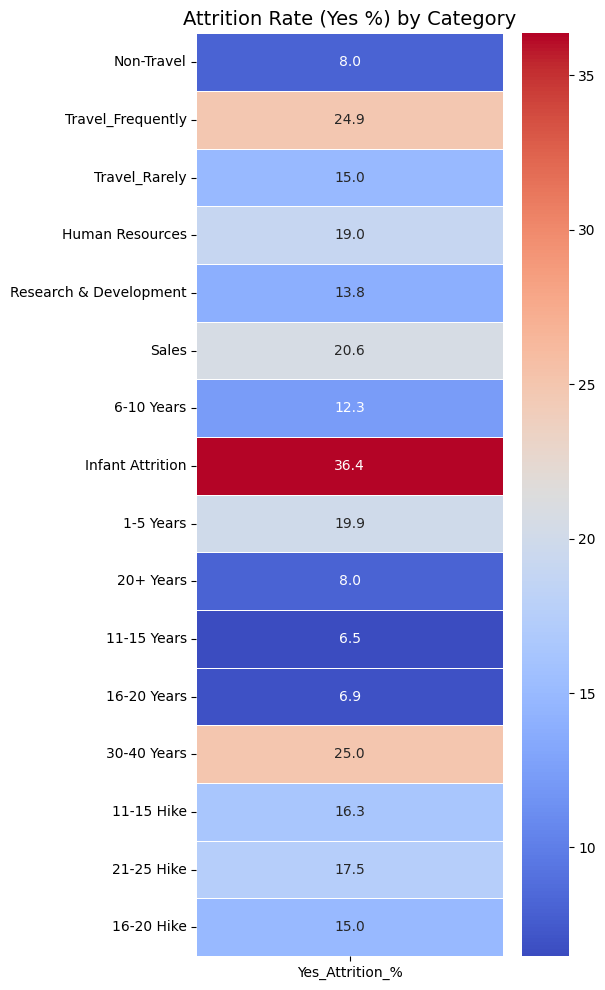

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Manual reconstruction of your 4 pivot tables ----
business = pd.DataFrame({
    "No": [138, 208, 887],
    "Yes": [12, 69, 156]
}, index=["Non-Travel", "Travel_Frequently", "Travel_Rarely"])

department = pd.DataFrame({
    "No": [51, 828, 354],
    "Yes": [12, 133, 92]
}, index=["Human Resources", "Research & Development", "Sales"])

years = pd.DataFrame({
    "No": [393, 28, 586, 46, 101, 67, 12],
    "Yes": [55, 16, 146, 4, 7, 5, 4]
}, index=["6-10 Years", "Infant Attrition", "1-5 Years", "20+ Years",
          "11-15 Years", "16-20 Years", "30-40 Years"])

hike = pd.DataFrame({
    "No": [769, 141, 323],
    "Yes": [150, 30, 57]
}, index=["11-15 Hike", "21-25 Hike", "16-20 Hike"])

# ---- Helper function to compute "Yes" percentage per category ----
def yes_ratio(df):
    df = df.copy()
    df["Total"] = df["No"] + df["Yes"]
    df["Yes%"] = df["Yes"] / df["Total"] * 100
    return df[["Yes%"]]

# ---- Compute Yes% for all ----
b = yes_ratio(business)
d = yes_ratio(department)
y = yes_ratio(years)
h = yes_ratio(hike)

# ---- Combine all categories into one DataFrame ----
combined = pd.concat([
    b.rename_axis("Business Travel").rename(columns={"Yes%": "Yes_Attrition_%"}),
    d.rename_axis("Department").rename(columns={"Yes%": "Yes_Attrition_%"}),
    y.rename_axis("YearsAtCompany").rename(columns={"Yes%": "Yes_Attrition_%"}),
    h.rename_axis("Hike").rename(columns={"Yes%": "Yes_Attrition_%"})
])

# ---- Plot heatmap of "Yes%" to visualize attrition intensity ----
plt.figure(figsize=(6, 10))
sns.heatmap(combined, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".1f")
plt.title("Attrition Rate (Yes %) by Category", fontsize=14)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()
